In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv("bonus_dataset.csv")
df.head()

,employee_id,performance,years_of_experience,projects_completed,bonus
0,EMP_001,7,2,4,124
1,EMP_002,4,1,4,82
2,EMP_003,8,7,10,178
3,EMP_004,5,7,8,138
4,EMP_005,7,8,9,170


In [3]:
type(df.performance), type(df.performance.values)

(pandas.core.series.Series, numpy.ndarray)

In [4]:
#equation = w1 * performance + w2*experience + w3*projects + bias

In [5]:
performance = torch.tensor(df.performance.values,dtype=torch.float32)
experience = torch.tensor(df.years_of_experience.values,dtype=torch.float32)
projects = torch.tensor(df.projects_completed.values,dtype=torch.float32)
bonus = torch.tensor(df.bonus.values,dtype=torch.float32)

In [6]:
w1 = torch.rand(1,requires_grad=True)
w2 = torch.rand(1,requires_grad=True)
w3 = torch.rand(1,requires_grad=True)
bias = torch.rand(1,requires_grad=True)

In [7]:
lr = 0.006
epochs = 5000
loss_hist = []
for epoch in range(epochs):
    predicted_bonus = w1*performance + w2*experience + w3*projects + bias
    loss = ((predicted_bonus-bonus)**2).mean()
    loss_hist.append(loss.item())
    loss.backward()
    
    with torch.no_grad():
        w1 -= lr*w1.grad
        w2 -= lr*w2.grad
        w3 -= lr*w3.grad
        bias -= lr*bias.grad
    
    w1.grad.zero_()
    w2.grad.zero_()
    w3.grad.zero_()
    bias.grad.zero_()

    if(epoch+1)%100 == 0:
        print(f"Epoch: [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")



Epoch: [100/5000], Loss: 16.8981
Epoch: [200/5000], Loss: 14.7463
Epoch: [300/5000], Loss: 12.8694
Epoch: [400/5000], Loss: 11.2316
Epoch: [500/5000], Loss: 9.8023
Epoch: [600/5000], Loss: 8.5549
Epoch: [700/5000], Loss: 7.4662
Epoch: [800/5000], Loss: 6.5161
Epoch: [900/5000], Loss: 5.6869
Epoch: [1000/5000], Loss: 4.9632
Epoch: [1100/5000], Loss: 4.3316
Epoch: [1200/5000], Loss: 3.7804
Epoch: [1300/5000], Loss: 3.2993
Epoch: [1400/5000], Loss: 2.8795
Epoch: [1500/5000], Loss: 2.5130
Epoch: [1600/5000], Loss: 2.1932
Epoch: [1700/5000], Loss: 1.9141
Epoch: [1800/5000], Loss: 1.6705
Epoch: [1900/5000], Loss: 1.4580
Epoch: [2000/5000], Loss: 1.2724
Epoch: [2100/5000], Loss: 1.1105
Epoch: [2200/5000], Loss: 0.9692
Epoch: [2300/5000], Loss: 0.8459
Epoch: [2400/5000], Loss: 0.7382
Epoch: [2500/5000], Loss: 0.6443
Epoch: [2600/5000], Loss: 0.5623
Epoch: [2700/5000], Loss: 0.4907
Epoch: [2800/5000], Loss: 0.4283
Epoch: [2900/5000], Loss: 0.3738
Epoch: [3000/5000], Loss: 0.3262
Epoch: [3100/50

In [8]:
print(f"Learned weights and bias: \nw1: {w1.item():.2f},\nw2:{w2.item():.2f},\nw3:{w3.item():.2f},\nbias:{bias.item():.2f}")

Learned weights and bias: 
w1: 12.03,
w2:5.91,
w3:2.12,
bias:19.41


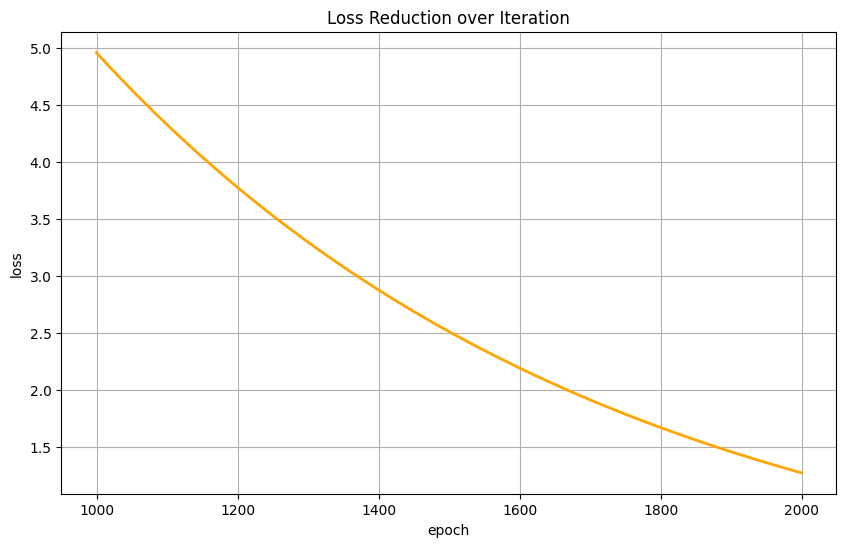

In [22]:
def show_graph(epoch,loss,title):
    plt.figure(figsize=(10,6))
    plt.plot(epoch,loss,linewidth=2,color='orange')
    plt.grid(True)
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.show()
show_graph(range(1000,2000),loss_hist[1000:2000],"Loss Reduction over Iteration")

### Mini Batch GD

In [10]:
n_samples = len(df.performance)
batch_size = 16
for i in range(0,n_samples,batch_size):
    print(i)

0
16
32
48
64
80
96


In [11]:
df.head(3)

,employee_id,performance,years_of_experience,projects_completed,bonus
0,EMP_001,7,2,4,124
1,EMP_002,4,1,4,82
2,EMP_003,8,7,10,178


In [12]:
w1 = torch.rand(1,requires_grad=True)
w2 = torch.rand(1,requires_grad=True)
w3 = torch.rand(1,requires_grad=True)
bias = torch.rand(1,requires_grad=True)

lr = 0.001
epochs = 5000
batch_loss_hist = []
for epoch in range(epochs):
    for i in range(0,n_samples,batch_size):
        batch_performance = performance[i:i+batch_size]
        batch_experience = experience[i:i+batch_size]
        batch_projects = projects[i:i+batch_size]
        batch_bonus = bonus[i:i+batch_size]
    
        predicted_batch_bonus = w1*batch_performance + w2*batch_experience + w3*batch_projects + bias
    
        batch_loss = ((predicted_batch_bonus - batch_bonus)**2).mean()
        batch_loss_hist.append(batch_loss.item())
        batch_loss.backward()
    
        with torch.no_grad():
            w1 -= lr*w1.grad
            w2 -= lr*w2.grad
            w3 -= lr*w3.grad
            bias -= lr*bias.grad
            
        w1.grad.zero_()
        w2.grad.zero_()
        w3.grad.zero_()
        bias.grad.zero_()
        
    if (epoch+1)%100 ==0:
        print(f"Epoch: [{epoch+1}/{epochs}], Loss: {batch_loss.item():.4f}")
        

Epoch: [100/5000], Loss: 11.9257
Epoch: [200/5000], Loss: 9.9843
Epoch: [300/5000], Loss: 8.4505
Epoch: [400/5000], Loss: 7.1938
Epoch: [500/5000], Loss: 6.1427
Epoch: [600/5000], Loss: 5.2536
Epoch: [700/5000], Loss: 4.4971
Epoch: [800/5000], Loss: 3.8512
Epoch: [900/5000], Loss: 3.2989
Epoch: [1000/5000], Loss: 2.8262
Epoch: [1100/5000], Loss: 2.4213
Epoch: [1200/5000], Loss: 2.0745
Epoch: [1300/5000], Loss: 1.7774
Epoch: [1400/5000], Loss: 1.5229
Epoch: [1500/5000], Loss: 1.3048
Epoch: [1600/5000], Loss: 1.1180
Epoch: [1700/5000], Loss: 0.9579
Epoch: [1800/5000], Loss: 0.8208
Epoch: [1900/5000], Loss: 0.7032
Epoch: [2000/5000], Loss: 0.6025
Epoch: [2100/5000], Loss: 0.5163
Epoch: [2200/5000], Loss: 0.4423
Epoch: [2300/5000], Loss: 0.3790
Epoch: [2400/5000], Loss: 0.3247
Epoch: [2500/5000], Loss: 0.2782
Epoch: [2600/5000], Loss: 0.2384
Epoch: [2700/5000], Loss: 0.2043
Epoch: [2800/5000], Loss: 0.1750
Epoch: [2900/5000], Loss: 0.1500
Epoch: [3000/5000], Loss: 0.1285
Epoch: [3100/5000]

In [14]:
len(batch_loss_hist)

35000

In [16]:
batch_loss_hist[1000:2000]

[11.028449058532715,
 9.648069381713867,
 6.592984676361084,
 19.431686401367188,
 15.086742401123047,
 25.05718994140625,
 17.11665916442871,
 11.008808135986328,
 9.633875846862793,
 6.581996917724609,
 19.401840209960938,
 15.064605712890625,
 25.01905632019043,
 17.090471267700195,
 10.98917007446289,
 9.619674682617188,
 6.570995330810547,
 19.372079849243164,
 15.042463302612305,
 24.98097801208496,
 17.064300537109375,
 10.969648361206055,
 9.605501174926758,
 6.560070514678955,
 19.342275619506836,
 15.020317077636719,
 24.942960739135742,
 17.038188934326172,
 10.950204849243164,
 9.591304779052734,
 6.549117565155029,
 19.31261444091797,
 14.998273849487305,
 24.90502166748047,
 17.012123107910156,
 10.930766105651855,
 9.577190399169922,
 6.538229465484619,
 19.28293800354004,
 14.976194381713867,
 24.867103576660156,
 16.986074447631836,
 10.911351203918457,
 9.563044548034668,
 6.527340412139893,
 19.253307342529297,
 14.954169273376465,
 24.829267501831055,
 16.9600982666

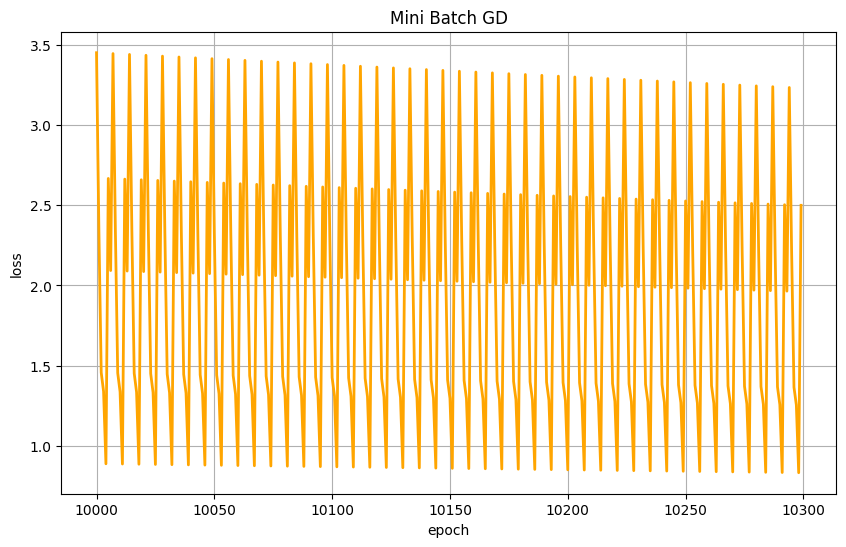

In [23]:
show_graph(range(10000,10300),batch_loss_hist[10000:10300],"Mini Batch GD")